# Análisis Estadístico de Evaluaciones de Gramáticas

Este notebook contiene el análisis estadístico riguroso de las evaluaciones de los modelos.
Se abordan problemas metodológicos como la **pseudorreplicación** (tratar múltiples ejecuciones de una misma consulta como independientes) y se proponen soluciones como la agregación por medianas/medias por consulta, el uso de T-tests emparejados y el cálculo del tamaño del efecto (d de Cohen).

In [48]:
import pandas as pd
import numpy as np
from scipy import stats
import sys
import warnings
warnings.filterwarnings('ignore')

# Añadir el path al repositorio para poder importar utilidades si es necesario
sys.path.append(r"D:\TFM\Model Evaluation")
from utils import compute_confidence_interval_with_method

## 1. Carga de Datos Brutos
Cargamos el archivo que contiene todas las ejecuciones individuales. En nuestra evaluación, cada consulta fue ejecutada 30 veces por modelo para capturar la varianza introducida por la temperatura del LLM.

In [49]:
base_dir = r"D:\TFM\Model Evaluation\outputs\grammar_eval\combined"
df_all = pd.read_csv(f"{base_dir}\\scores_all_evaluations.csv")

# Calculamos la puntuación ponderada para cada ejecución individual
df_all['Weighted_Score'] = df_all['Eval Score'] * df_all['Criterion Weight']
df_all['Weighted_Supported'] = df_all['Supported_Score'] * df_all['Criterion Weight']

def calc_run_scores(x):
    total_weight = x['Criterion Weight'].sum()
    overall = x['Weighted_Score'].sum() / total_weight
    supported = np.nan if x['Supported_Score'].isna().all() else (x['Weighted_Supported'].sum() / total_weight)
    return pd.Series({'Run_Overall_Score': overall, 'Run_Supported_Score': supported})

# Agrupamos a nivel de "Ejecución" (Run)
run_scores = df_all.groupby(['Grammar', 'Model', 'Thinking', 'Query ID', 'Run']).apply(calc_run_scores).reset_index()
run_scores.head()

,Grammar,Model,Thinking,Query ID,Run,Run_Overall_Score,Run_Supported_Score
0,graphq_tree,gemma4:26b,False,Q01,1,0.85,0.85
1,graphq_tree,gemma4:26b,False,Q01,2,0.85,0.85
2,graphq_tree,gemma4:26b,False,Q01,3,0.85,0.85
3,graphq_tree,gemma4:26b,False,Q01,4,0.85,0.85
4,graphq_tree,gemma4:26b,False,Q01,5,0.85,0.85


## 2. Corrección de la Pseudorreplicación
Si calculamos un intervalo de confianza usando todas las ejecuciones (N=1350), estamos violando el supuesto de independencia. La solución correcta es agregar las 30 ejecuciones de cada consulta en una única métrica (la **mediana** o la **media**), reduciendo nuestro tamaño muestral a las consultas únicas (N=45).

In [50]:
# Calculamos la Mediana de las 30 ejecuciones para cada consulta
query_medians = run_scores.groupby(['Grammar', 'Model', 'Thinking', 'Query ID'])[['Run_Overall_Score', 'Run_Supported_Score']].median().reset_index()
query_medians.rename(columns={'Run_Overall_Score': 'Median_Overall_Score', 'Run_Supported_Score': 'Supported_Median'}, inplace=True)

# Calculamos la Media de las 30 ejecuciones para cada consulta
query_means = run_scores.groupby(['Grammar', 'Model', 'Thinking', 'Query ID'])[['Run_Overall_Score', 'Run_Supported_Score']].mean().reset_index()
query_means.rename(columns={'Run_Overall_Score': 'Mean_Overall_Score', 'Run_Supported_Score': 'Supported_Mean'}, inplace=True)

display(query_medians.head())

,Grammar,Model,Thinking,Query ID,Median_Overall_Score,Supported_Median
0,graphq_tree,gemma4:26b,False,Q01,0.85,0.85
1,graphq_tree,gemma4:26b,False,Q02,0.00,NaN
2,graphq_tree,gemma4:26b,False,Q03,0.20,0.20
3,graphq_tree,gemma4:26b,False,Q04,0.00,NaN
4,graphq_tree,gemma4:26b,False,Q05,0.00,NaN


## 3. Comparativa: Mejor Modelo vs Segundo Mejor por Gramática (T-Test Emparejado)
Ya que los modelos se evalúan sobre exactamente las mismas 45 consultas, utilizamos un **T-test emparejado** para ver si existen diferencias reales entre los modelos más competitivos de cada prompt.

**Interpretación del P-valor:**
* **p < 0.05**: La diferencia entre los modelos es **estadísticamente significativa**. Podemos afirmar con confianza que un modelo es mejor que otro.
* **p ≥ 0.05**: La diferencia **NO es significativa**. Se considera estadísticamente un "empate técnico", y las variaciones observadas podrían deberse al azar.

In [51]:
results = []
for grammar in query_medians['Grammar'].unique():
    subset = query_medians[query_medians['Grammar'] == grammar]
    
    # Encontramos los dos mejores modelos para esta gramática
    model_scores = subset.groupby('Model')['Median_Overall_Score'].mean().sort_values(ascending=False)
    if len(model_scores) < 2: continue
        
    best_model, second_best = model_scores.index[0], model_scores.index[1]
    
    b_scores = subset[subset['Model'] == best_model].sort_values('Query ID')['Median_Overall_Score'].values
    s_scores = subset[subset['Model'] == second_best].sort_values('Query ID')['Median_Overall_Score'].values
    
    # Paired t-test
    t_stat, p_ttest = stats.ttest_rel(b_scores, s_scores)
    
    interpretation = "Significativo (Es Mejor)" if p_ttest < 0.05 else "No Significativo (Empate Técnico)"
        
    results.append({
        'Gramática': grammar,
        'Mejor Modelo': best_model,
        '2º Mejor': second_best,
        'Diferencia': f"+{(model_scores.iloc[0] - model_scores.iloc[1]):.4f}",
        'P-valor': f"{p_ttest:.4f}",
        'Interpretación': interpretation
    })

df_ttest = pd.DataFrame(results)
display(df_ttest)

,Gramática,Mejor Modelo,2º Mejor,Diferencia,P-valor,Interpretación
0,graphq_tree,qwen3.6:35b,gemma4:26b,+0.0167,0.5052,No Significativo (Empate Técnico)
1,lambda_dcs,qwen3.6:35b,ministral-3:14b,+0.0300,0.1312,No Significativo (Empate Técnico)
2,nsqa,qwen3.6:35b,ministral-3:14b,+0.0172,0.4795,No Significativo (Empate Técnico)
3,pccg_cgg_lambda,gemma4:26b,qwen3.6:35b,+0.0011,0.9637,No Significativo (Empate Técnico)
4,semgir,gemma4:26b,qwen3.6:35b,+0.1150,0.0076,Significativo (Es Mejor)
5,semgir_base,gemma4:26b,qwen3.6:35b,+0.0944,0.0104,Significativo (Es Mejor)
6,squall,gemma4:26b,qwen3.6:35b,+0.0078,0.8277,No Significativo (Empate Técnico)


## 4. Tamaño del Efecto (d de Cohen)
Incluso cuando un test es significativo, necesitamos saber la magnitud real de esa diferencia usando la **d de Cohen para datos emparejados ($d_z$)**.

**Interpretación de Cohen (1988):**
* **d < 0.2**: Efecto trivial / despreciable.
* **d ≈ 0.2**: Efecto pequeño.
* **d ≈ 0.5**: Efecto moderado / medio.
* **d ≈ 0.8**: Efecto grande.

In [52]:
def interpret_cohen(d):
    abs_d = abs(d)
    if abs_d < 0.2:
        return "Trivial"
    elif abs_d < 0.5:
        return "Pequeño a Moderado"
    elif abs_d < 0.8:
        return "Moderado"
    else:
        return "Grande"

effect_sizes = []
for grammar in query_medians['Grammar'].unique():
    subset = query_medians[query_medians['Grammar'] == grammar]
    
    model_scores = subset.groupby('Model')['Median_Overall_Score'].mean().sort_values(ascending=False)
    if len(model_scores) < 2: continue
        
    best_model, second_best = model_scores.index[0], model_scores.index[1]
    b_scores = subset[subset['Model'] == best_model].sort_values('Query ID')['Median_Overall_Score'].values
    s_scores = subset[subset['Model'] == second_best].sort_values('Query ID')['Median_Overall_Score'].values
    
    diffs = b_scores - s_scores
    std_diff = diffs.std(ddof=1)
    cohen_d = diffs.mean() / std_diff if std_diff != 0 else 0
    
    effect_sizes.append({
        'Gramática': grammar,
        'Comparativa': f"{best_model} vs {second_best}",
        'd de Cohen': f"{cohen_d:.4f}",
        'Impacto (Interpretación)': interpret_cohen(cohen_d)
    })

df_cohen = pd.DataFrame(effect_sizes)
display(df_cohen)

,Gramática,Comparativa,d de Cohen,Impacto (Interpretación)
0,graphq_tree,qwen3.6:35b vs gemma4:26b,0.1001,Trivial
1,lambda_dcs,qwen3.6:35b vs ministral-3:14b,0.2293,Pequeño a Moderado
2,nsqa,qwen3.6:35b vs ministral-3:14b,0.1063,Trivial
3,pccg_cgg_lambda,gemma4:26b vs qwen3.6:35b,0.0068,Trivial
4,semgir,gemma4:26b vs qwen3.6:35b,0.4172,Pequeño a Moderado
5,semgir_base,gemma4:26b vs qwen3.6:35b,0.3993,Pequeño a Moderado
6,squall,gemma4:26b vs qwen3.6:35b,0.0326,Trivial


## 5. Comparativa Interna: Semgir vs Semgir Base
Analizamos estadísticamente si la versión completa de `semgir` aporta una mejora significativa sobre su versión `semgir_base`.

In [53]:
semgir = query_medians[query_medians['Grammar'] == 'semgir']
base = query_medians[query_medians['Grammar'] == 'semgir_base']

merged_sb = pd.merge(semgir, base, on=['Model', 'Query ID'], suffixes=('_semgir', '_base'))

def compare_sb(df_model):
    diffs = df_model['Median_Overall_Score_semgir'] - df_model['Median_Overall_Score_base']
    t, p = stats.ttest_rel(df_model['Median_Overall_Score_semgir'], df_model['Median_Overall_Score_base'])
    cohen_d = diffs.mean() / diffs.std(ddof=1) if diffs.std(ddof=1) != 0 else 0
    
    return pd.Series({
        'Puntuación Semgir': f"{df_model['Median_Overall_Score_semgir'].mean():.4f}",
        'Puntuación Base': f"{df_model['Median_Overall_Score_base'].mean():.4f}",
        'Diferencia': f"+{diffs.mean():.4f}" if diffs.mean() > 0 else f"{diffs.mean():.4f}",
        'P-valor': f"{p:.4f}",
        'Significativo?': "Sí" if p < 0.05 else "No (Empate)",
        'd de Cohen': f"{cohen_d:.4f}",
        'Impacto': interpret_cohen(cohen_d)
    })

comparison_sb = merged_sb.groupby('Model').apply(compare_sb)
display(comparison_sb)

# Global test (Promedio a través de todos los modelos)
diffs_global_sb = merged_sb['Median_Overall_Score_semgir'] - merged_sb['Median_Overall_Score_base']
t_g_sb, p_g_sb = stats.ttest_rel(merged_sb['Median_Overall_Score_semgir'], merged_sb['Median_Overall_Score_base'])
d_g_sb = diffs_global_sb.mean() / diffs_global_sb.std(ddof=1)

print("\n=== RESULTADO GLOBAL (Semgir vs Semgir Base) ===")
print(f"P-valor (T-test): {p_g_sb:.4f} -> {'Significativo' if p_g_sb < 0.05 else 'No Significativo'}")
print(f"d de Cohen: {d_g_sb:.4f} -> {interpret_cohen(d_g_sb)}")

,Puntuación Semgir,Puntuación Base,Diferencia,P-valor,Significativo?,d de Cohen,Impacto
Model,,,,,,,
gemma4:26b,0.9194,0.8800,+0.0394,0.2370,No (Empate),0.1787,Trivial
ministral-3:14b,0.7122,0.7167,-0.0044,0.8943,No (Empate),-0.0199,Trivial
qwen3.6:35b,0.8044,0.7856,+0.0189,0.6171,No (Empate),0.0751,Trivial



=== RESULTADO GLOBAL (Semgir vs Semgir Base) ===
P-valor (T-test): 0.3683 -> No Significativo
d de Cohen: 0.0777 -> Trivial


## 6. Comparativa Externa: Familia Semgir vs Alternativas (Squall)
Para justificar que el enfoque Semgir es netamente superior al resto de gramáticas heredadas, comparamos las gramáticas Semgir contra la mejor gramática alternativa evaluada, que es `squall`.

In [54]:
squall = query_medians[query_medians['Grammar'] == 'squall']

# Comparar semgir vs squall
merged_ss = pd.merge(semgir, squall, on=['Model', 'Query ID'], suffixes=('_semgir', '_squall'))

def compare_squall(df_model, col1, col2, name1, name2):
    diffs = df_model[col1] - df_model[col2]
    t, p = stats.ttest_rel(df_model[col1], df_model[col2])
    cohen_d = diffs.mean() / diffs.std(ddof=1) if diffs.std(ddof=1) != 0 else 0
    return pd.Series({
        f'Pts {name1}': f"{df_model[col1].mean():.4f}",
        f'Pts {name2}': f"{df_model[col2].mean():.4f}",
        'Diferencia': f"+{diffs.mean():.4f}" if diffs.mean() > 0 else f"{diffs.mean():.4f}",
        'P-valor': f"{p:.4f}",
        'Significativo?': "Sí" if p < 0.05 else "No (Empate)",
        'd de Cohen': f"{cohen_d:.4f}",
        'Impacto': interpret_cohen(cohen_d)
    })

print("=== COMPARATIVA: SEMGIR vs SQUALL ===")
comparison_ss = merged_ss.groupby('Model').apply(compare_squall, 'Median_Overall_Score_semgir', 'Median_Overall_Score_squall', 'Semgir', 'Squall')
display(comparison_ss)

# Comparar semgir_base vs squall
merged_sbs = pd.merge(base, squall, on=['Model', 'Query ID'], suffixes=('_base', '_squall'))
print("\n=== COMPARATIVA: SEMGIR BASE vs SQUALL ===")
comparison_sbs = merged_sbs.groupby('Model').apply(compare_squall, 'Median_Overall_Score_base', 'Median_Overall_Score_squall', 'Semgir Base', 'Squall')
display(comparison_sbs)

=== COMPARATIVA: SEMGIR vs SQUALL ===


,Pts Semgir,Pts Squall,Diferencia,P-valor,Significativo?,d de Cohen,Impacto
Model,,,,,,,
gemma4:26b,0.9194,0.6728,+0.2467,0.0000,Sí,0.6897,Moderado
ministral-3:14b,0.7122,0.6422,+0.0700,0.2364,No (Empate),0.1790,Trivial
qwen3.6:35b,0.8044,0.6650,+0.1394,0.0319,Sí,0.3303,Pequeño a Moderado



=== COMPARATIVA: SEMGIR BASE vs SQUALL ===


,Pts Semgir Base,Pts Squall,Diferencia,P-valor,Significativo?,d de Cohen,Impacto
Model,,,,,,,
gemma4:26b,0.8800,0.6728,+0.2072,0.0005,Sí,0.5647,Moderado
ministral-3:14b,0.7167,0.6422,+0.0744,0.2681,No (Empate),0.1672,Trivial
qwen3.6:35b,0.7856,0.6650,+0.1206,0.0640,No (Empate),0.2832,Pequeño a Moderado


## 7. Visualización: Rendimiento por Gramática y Modelo
A continuación, representamos de forma visual el rendimiento (Media de las Medianas) de cada LLM en cada gramática. Las **barras de error (líneas negras)** sobre cada columna representan el **Intervalo de Confianza al 95%**.

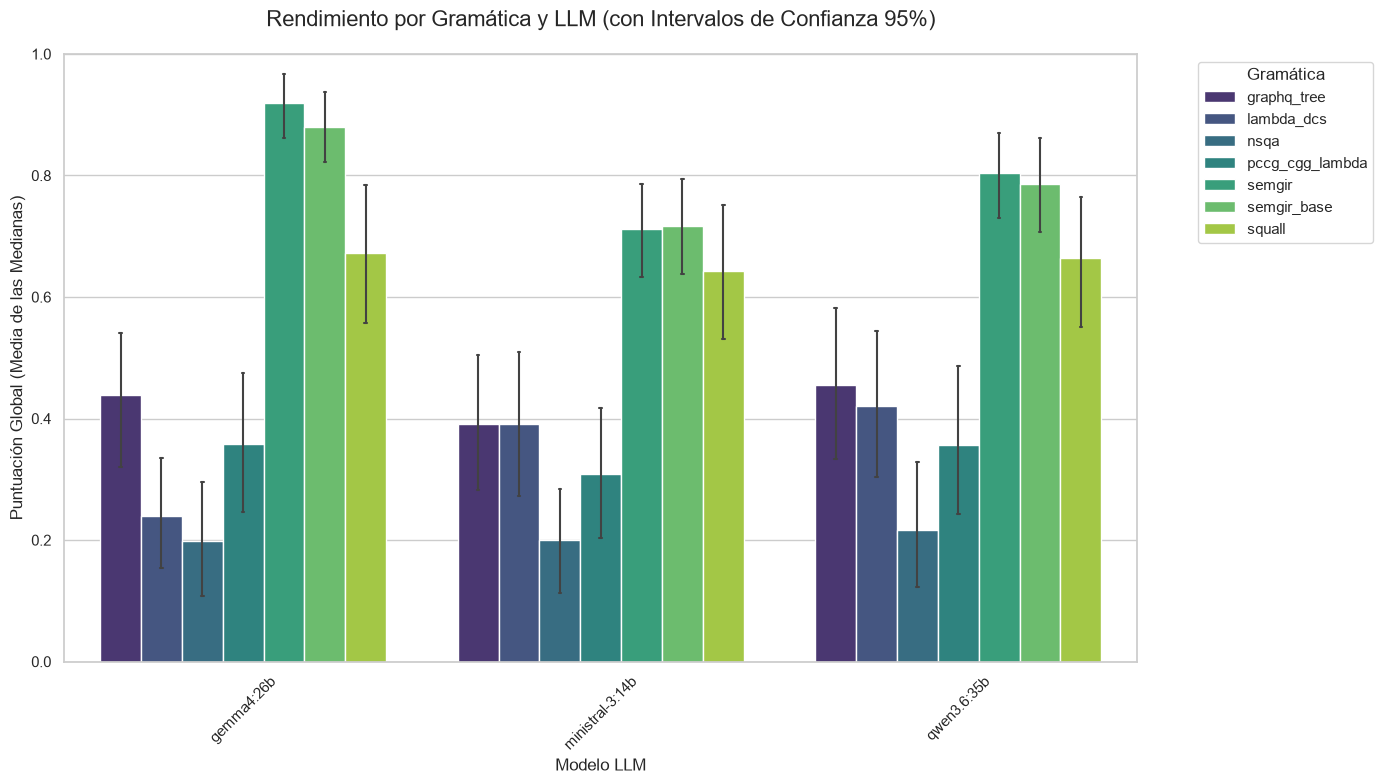

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo del gráfico
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# seaborn.barplot calcula automáticamente la media (Mean_of_Medians) 
# y añade las barras de error (Intervalo de confianza 95%) por defecto.
ax = sns.barplot(
    data=query_medians, 
    x='Model', 
    y='Median_Overall_Score', 
    hue='Grammar',
    palette='viridis',
    capsize=.05,
    err_kws={'linewidth': 1.5}
)

# Ajustes visuales
plt.title('Rendimiento por Gramática y LLM (con Intervalos de Confianza 95%)', fontsize=16, pad=20)
plt.xlabel('Modelo LLM', fontsize=12)
plt.ylabel('Puntuación Global (Media de las Medianas)', fontsize=12)
plt.ylim(0, 1) # La puntuación va de 0 a 1
plt.legend(title='Gramática', title_fontsize='12', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 8. Visualización (Basada en Medias): Rendimiento por Modelo y Gramática
Este gráfico es idéntico al anterior, pero en lugar de usar la media de las medianas, utiliza la **media de las medias** de cada consulta. Las barras de error siguen representando el **Intervalo de Confianza al 95%** corregido (N=45).

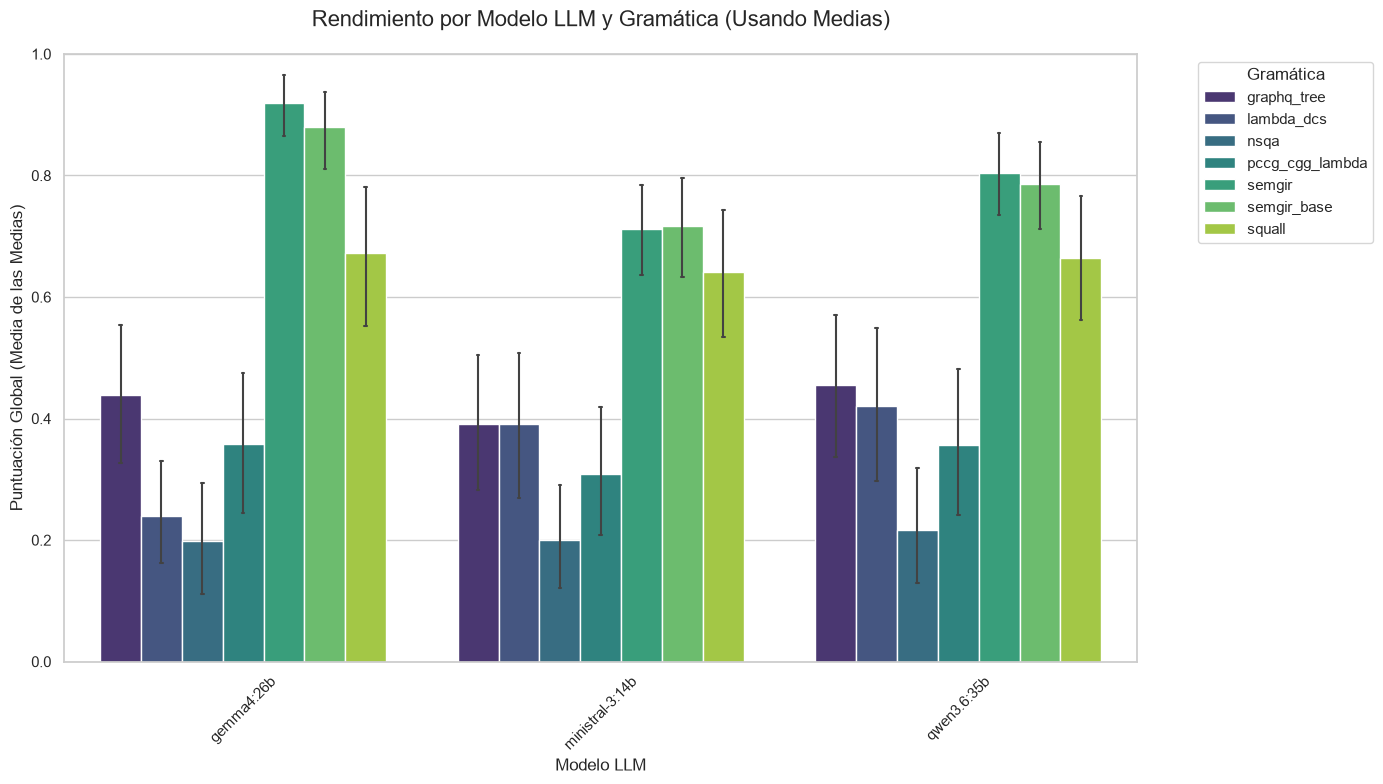

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo del gráfico
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=query_means, 
    x='Model', 
    y='Mean_Overall_Score', 
    hue='Grammar',
    palette='viridis',
    capsize=.05,
    err_kws={'linewidth': 1.5}
)

# Ajustes visuales
plt.title('Rendimiento por Modelo LLM y Gramática (Usando Medias)', fontsize=16, pad=20)
plt.xlabel('Modelo LLM', fontsize=12)
plt.ylabel('Puntuación Global (Media de las Medias)', fontsize=12)
plt.ylim(0, 1)
plt.legend(title='Gramática', title_fontsize='12', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()